# CIFAR-10 Dense Feed-Forward Neural Network

This notebook applies a dense feed-forward neural network to CIFAR-10.

## CIFAR-10 Dense Classification

The experiment progresses from CIFAR-10 preprocessing and visualization to dense-network training and a shuffled-feature comparison.

**Dense Feedforward Neural Network for Image Classification**

We will use a dense neural network to classify the CIFAR-10 dataset, which consists of 32-by-32 color images split into 10 classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print('Original shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

# Convert images to single row
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1441s 8us/step
Original shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 1)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)
Final shapes
x_train.shape = (50000, 3072)
y_train.shape = (50000, 10)
x_test.shape = (10000, 3072)
y_test.shape = (10000, 10)


In [3]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

Let's see some of the images in the dataset

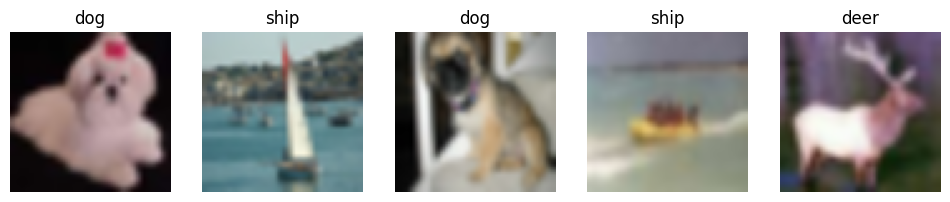

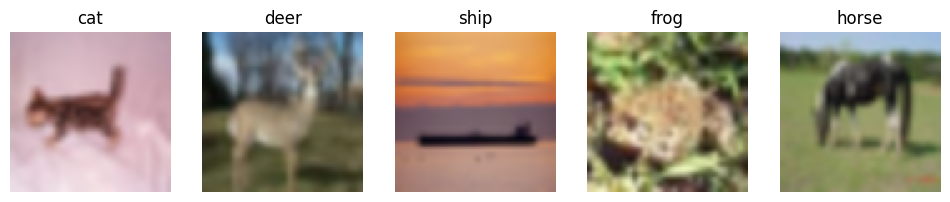

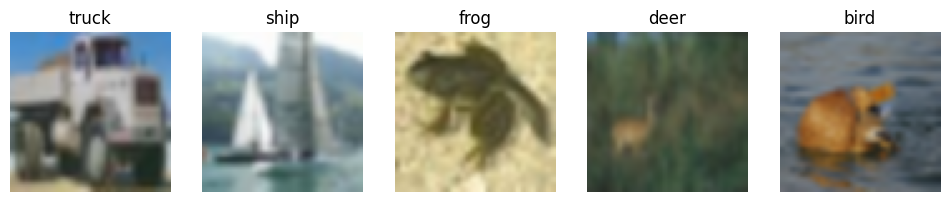

In [4]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s].reshape(32,32,3), (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792,010 (6.84 MB)

 Trainable params: 1,792,010 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 - 4s - 40ms/step - accuracy: 0.2866 - loss: 2.0016 - val_accuracy: 0.3508 - val_loss: 1.8128
Epoch 2/40
100/100 - 1s - 8ms/step - accuracy: 0.3726 - loss: 1.7501 - val_accuracy: 0.4025 - val_loss: 1.6805
Epoch 3/40
100/100 - 1s - 7ms/step - accuracy: 0.4133 - loss: 1.6487 - val_accuracy: 0.4322 - val_loss: 1.5962
Epoch 4/40
100/100 - 1s - 7ms/step - accuracy: 0.4327 - loss: 1.5846 - val_accuracy: 0.4486 - val_loss: 1.5536
Epoch 5/40
100/100 - 1s - 7ms/step - accuracy: 0.4529 - loss: 1.5356 - val_accuracy: 0.4588 - val_loss: 1.5261
Epoch 6/40
100/100 - 1s - 7ms/step - accuracy: 0.4684 - loss: 1.4940 - val_accuracy: 0.4734 - val_loss: 1.4799
Epoch 7/40
100/100 - 1s - 13ms/step - accuracy: 0.4765 - loss: 1.4696 - val_accuracy: 0.4780 - val_loss: 1.4711
Epoch 8/40
100/100 - 1s - 7ms/step - accuracy: 0.4877 - loss: 1.4391 - val_accuracy: 0.4706 - val_loss: 1.4747
Epoch 9/40
100/100 - 1s - 7ms/step - accuracy: 0.5027 - loss: 1.4016 - val_accuracy: 0.4892 - val_loss: 1.4291

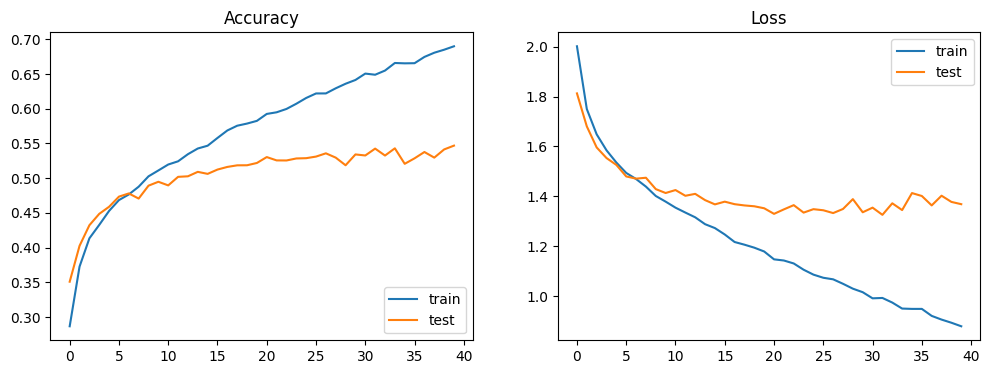

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 38.1270 secs
Mean squared error = 0.061
Accuracy = 0.5469
The highest training accuracy was 0.6900 obtained in epoch 40
The final training accuracy was 0.6900
The highest validation accuracy was 0.5469 obtained in epoch 40
The final validation accuracy was 0.5469
The lowest training loss was 0.8794 obtained in epoch 40
The final training loss was 0.8794
The lowest validation loss was 1.3261 obtained in epoch 32
The final validation loss was 1.3687


In [5]:
def ffnn(n_inputs,hidden_layers):
  model = tf.keras.Sequential()
  model.add(Input(shape=(n_inputs,)))
  for units in hidden_layers:
    model.add(Dense(units,  activation='relu'))
  model.add(Dense(10,  activation='softmax'))
  return model

model = ffnn(x_train.shape[1],[500,500])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 500,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

We obtain an accuracy of around 54%. We can see that the network starts overfitting, as the validation loss starts increasing around epoch 20 to 25.

## Randomly Shuffling the Columns of the Train and Test Arrays

Since the network treats each of the 3072 attributes independently, if we shuffle the columns in the training data, we expect to see the same performance. Let's see if this is the case.

In [6]:
ind = np.random.permutation(x_train.shape[1])
x_train = x_train[:,ind]
x_test = x_test[:,ind]

Now let's see the resulting images.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792,010 (6.84 MB)

 Trainable params: 1,792,010 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 - 3s - 27ms/step - accuracy: 0.2825 - loss: 2.0153 - val_accuracy: 0.3611 - val_loss: 1.7924
Epoch 2/40
100/100 - 1s - 8ms/step - accuracy: 0.3778 - loss: 1.7459 - val_accuracy: 0.3803 - val_loss: 1.7255
Epoch 3/40
100/100 - 1s - 7ms/step - accuracy: 0.4147 - loss: 1.6464 - val_accuracy: 0.4159 - val_loss: 1.6240
Epoch 4/40
100/100 - 1s - 7ms/step - accuracy: 0.4363 - loss: 1.5866 - val_accuracy: 0.4280 - val_loss: 1.6008
Epoch 5/40
100/100 - 1s - 7ms/step - accuracy: 0.4571 - loss: 1.5298 - val_accuracy: 0.4454 - val_loss: 1.5435
Epoch 6/40
100/100 - 1s - 7ms/step - accuracy: 0.4707 - loss: 1.4912 - val_accuracy: 0.4711 - val_loss: 1.4889
Epoch 7/40
100/100 - 1s - 7ms/step - accuracy: 0.4841 - loss: 1.4548 - val_accuracy: 0.4718 - val_loss: 1.4702
Epoch 8/40
100/100 - 1s - 7ms/step - accuracy: 0.4911 - loss: 1.4357 - val_accuracy: 0.4758 - val_loss: 1.4780
Epoch 9/40
100/100 - 1s - 13ms/step - accuracy: 0.5035 - loss: 1.4016 - val_accuracy: 0.4905 - val_loss: 1.4448

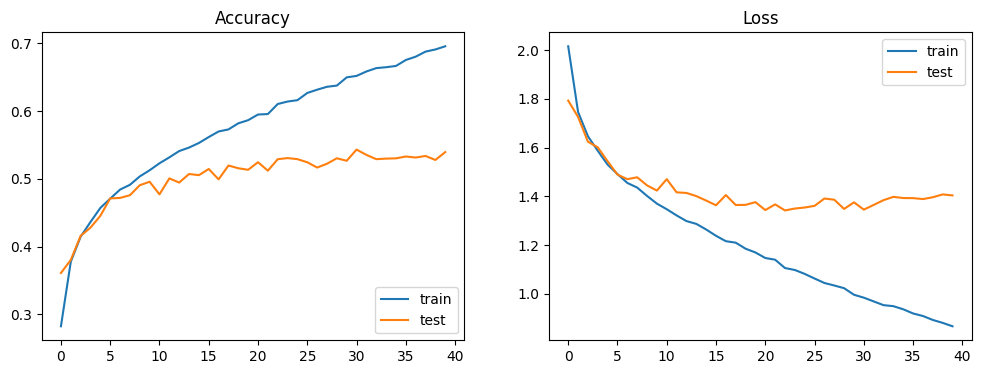

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 36.6617 secs
Mean squared error = 0.061
Accuracy = 0.5394
The highest training accuracy was 0.6955 obtained in epoch 40
The final training accuracy was 0.6955
The highest validation accuracy was 0.5431 obtained in epoch 31
The final validation accuracy was 0.5394
The lowest training loss was 0.8670 obtained in epoch 40
The final training loss was 0.8670
The lowest validation loss was 1.3421 obtained in epoch 23
The final validation loss was 1.4037


In [7]:
def ffnn(n_inputs,hidden_layers):
  model = tf.keras.Sequential()
  model.add(Input(shape=(n_inputs,)))
  for units in hidden_layers:
    model.add(Dense(units,  activation='relu'))
  model.add(Dense(10,  activation='softmax'))
  return model

model = ffnn(x_train.shape[1],[500,500])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 500,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

As expected, performance is nearly identical, even though the problem appears much more difficult. The reason for this is that the network fails to exploit features in the dataset that are unique to images, such as the fact that pixels are related to other neighboring pixels and form patterns.

Later we will experiment with convolutional neural networks, which exploit this type of relations.